## Task 1: Data Preprocessing

### Import Necessary Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

### Load the data & keep the relevant column

In [4]:
# Read the training, testing, and validation datasets from LIAR dataset
train = pd.read_csv("data/train.tsv", sep="\t", header=None)
validation = pd.read_csv("data/valid.tsv", sep="\t", header=None)
test = pd.read_csv("data/test.tsv", sep="\t", header=None)

In [5]:
# Print the data
print(train.head())
print(validation.head())
print(test.head())

           0            1                                                  2   \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                                   3               4                     5   \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

         6           7     8     9    

In [6]:
# Check the shapes of the datasets
print("Shape of TRAIN DATA: ", train.shape)
print("Shape of VALIDATION DATA: ", validation.shape)
print("Shape of TEST DATA: ", test.shape)

Shape of TRAIN DATA:  (10240, 14)
Shape of VALIDATION DATA:  (1284, 14)
Shape of TEST DATA:  (1267, 14)


In [7]:
# Only keep the relevant columns (label and statement)
train = train[[1, 2]]
validation = validation[[1, 2]]
test = test[[1, 2]]

In [8]:
# Print the updated data
print(train.head())
print(validation.head())
print(test.head())

             1                                                  2
0        false  Says the Annies List political group supports ...
1    half-true  When did the decline of coal start? It started...
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...
3        false  Health care reform legislation is likely to ma...
4    half-true  The economic turnaround started at the end of ...
             1                                                  2
0  barely-true  We have less Americans working now than in the...
1   pants-fire  When Obama was sworn into office, he DID NOT u...
2        false  Says Having organizations parading as being so...
3    half-true     Says nearly half of Oregons children are poor.
4    half-true  On attacks by Republicans that various program...
            1                                                  2
0        true  Building a wall on the U.S.-Mexico border will...
1       false  Wisconsin is on pace to double the number of l...
2       false

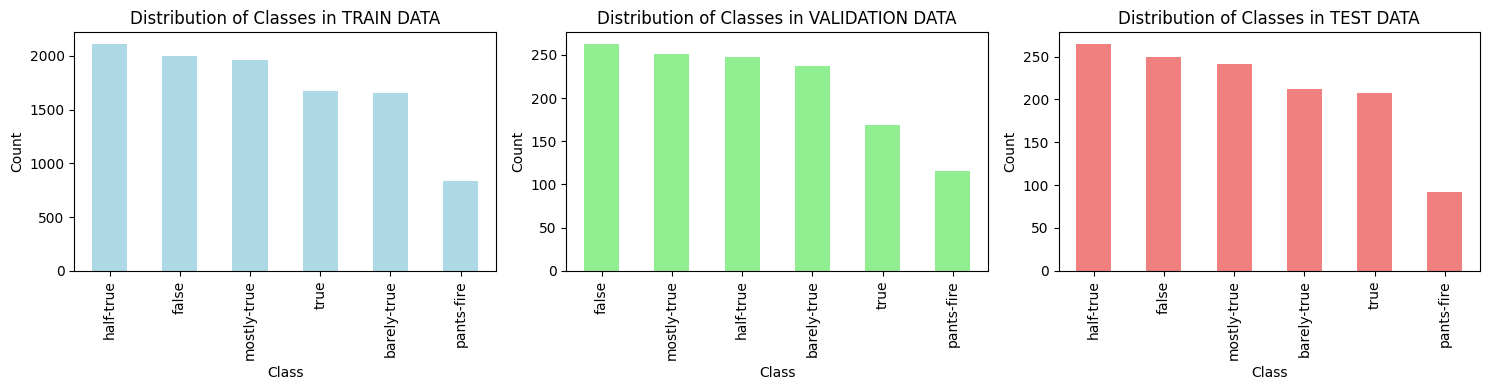

In [9]:
# Plot the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train[1].value_counts().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Distribution of Classes in TRAIN DATA')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

validation[1].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Classes in VALIDATION DATA')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

test[1].value_counts().plot(kind='bar', ax=axes[2], color='lightcoral')
axes[2].set_title('Distribution of Classes in TEST DATA')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Data Cleaning
Reference: https://www.geeksforgeeks.org/machine-learning/python-efficient-text-data-cleaning/

In [10]:
train_clean = train.copy()
validation_clean = validation.copy()
test_clean = test.copy()

In [11]:
def clean_text(text):
    # Step 1: Convert all text to lowercase, remove punctuation and remove whitespace
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())

    # Step 2: Remove URLs and Hashtags
    text = re.sub(r'https?:\/\/.\S+', "", text)
    text = re.sub(r'#', '', text)

    # Step 3: Contration Replacement (didn't to did not)
    shorten_dict={"'s":" is","n't":" not","'m":" am","'ll":" will",
           "'d":" would","'ve":" have","'re":" are"}
    for key, value in shorten_dict.items():
        if key in text:
            text = text.replace(key, value)

    return text

In [12]:
train_clean[2] = train_clean[2].apply(clean_text)
validation_clean[2] = validation_clean[2].apply(clean_text)
test_clean[2] = test_clean[2].apply(clean_text)

In [13]:
print(train_clean)

                 1                                                  2
0            false  says the annies list political group supports ...
1        half-true  when did the decline of coal start it started ...
2      mostly-true  hillary clinton agrees with john mccain by vot...
3            false  health care reform legislation is likely to ma...
4        half-true  the economic turnaround started at the end of ...
...            ...                                                ...
10235  mostly-true  there are a larger number of shark attacks in ...
10236  mostly-true  democrats have now become the party of the atl...
10237    half-true  says an alternative to social security that op...
10238        false  on lifting the us cuban embargo and allowing t...
10239   pants-fire  the department of veterans affairs has a manua...

[10240 rows x 2 columns]


In [14]:
print(train_clean[2])

0        says the annies list political group supports ...
1        when did the decline of coal start it started ...
2        hillary clinton agrees with john mccain by vot...
3        health care reform legislation is likely to ma...
4        the economic turnaround started at the end of ...
                               ...                        
10235    there are a larger number of shark attacks in ...
10236    democrats have now become the party of the atl...
10237    says an alternative to social security that op...
10238    on lifting the us cuban embargo and allowing t...
10239    the department of veterans affairs has a manua...
Name: 2, Length: 10240, dtype: object


In [15]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train_clean.head())

             1  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                          2  
0                                                          says the annies list political group supports thirdtrimester abortions on demand  
1  when did the decline of coal start it started when natural gas took off that started to begin in president george w bushs administration  
2                                    hillary clinton agrees with john mccain by voting to give george bush the benefit of the doubt on iran  
3                                                             health care reform legislation is likely to mandate free sex change surgeries  
4                                                                                     the economic turnaround started at the end of my term  


In [16]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train.head())

             1  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                               2  
0                                                             Says the Annies List political group supports third-trimester abortions on demand.  
1  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.  
2                                      Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."  
3                                                                 Health care reform legislation is likely to mandate free sex change surgeries.  
4                                                                                         The economic turnaround started at the end of my term.  


## Task 2: BiLSTM Baseline


Reference: https://www.geeksforgeeks.org/nlp/bidirectional-lstm-in-nlp/ -> but ours are not just true or false so we can't use vectorization


### Encode Labels
Convert the labels such as false, true, etc. into numbers


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_labels = label_encoder.fit_transform(train_clean[1])
val_labels = label_encoder.transform(validation_clean[1])
test_labels = label_encoder.transform(test_clean[1])

print(label_encoder.classes_)

['barely-true' 'false' 'half-true' 'mostly-true' 'pants-fire' 'true']


### Tokenization

In [18]:
MAX_VOCAB = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean[2])

train_seq = tokenizer.texts_to_sequences(train_clean[2])
val_seq = tokenizer.texts_to_sequences(validation_clean[2])
test_seq = tokenizer.texts_to_sequences(test_clean[2])

train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post')
val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding='post')
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post')

### Train the BiLSTM
Reference: https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

In [19]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense

# Define the model architecture
model = Sequential()

# Add an embedding layer to convert input sequences to dense vectors
model.add(Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN))

# Add a Bidirectional LSTM layer
model.add(Bidirectional(LSTM(units=64, return_sequences=False)))

# Add a dense output layer
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=6, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_pad, train_labels,
    validation_data=(val_pad, val_labels),
    epochs=5,
    batch_size=32
)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.2266 - loss: 1.7383 - val_accuracy: 0.2477 - val_loss: 1.6998
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3184 - loss: 1.5989 - val_accuracy: 0.2477 - val_loss: 1.7335
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4787 - loss: 1.3079 - val_accuracy: 0.2360 - val_loss: 1.9017
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6494 - loss: 0.9397 - val_accuracy: 0.2352 - val_loss: 2.2015
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7795 - loss: 0.6298 - val_accuracy: 0.2321 - val_loss: 2.7232


In [21]:
test_loss, test_acc = model.evaluate(test_pad, test_labels)
print(f"Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2376 - loss: 2.6580
Test Accuracy: 0.2376


## Task 3: BERT

Reference:

- https://medium.com/@info.codetitan/analyzing-fake-news-with-transformers-484b537c6f0e
- https://medium.com/@piyushkashyap045/guide-to-tokenization-and-padding-with-bert-transforming-text-into-machine-readable-data-5a24bf59d36b

- https://medium.com/data-science/a-complete-guide-to-bert-with-code-9f87602e4a11 (most relevant to the code)

### Tokenize the text

In [32]:
# Load a BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the training data
train_tokens = bert_tokenizer(
    train_clean[2].tolist(),
    padding=True,
    truncation=True,
    max_length = 128)

# Tokenize the validation data
val_tokens = bert_tokenizer(
    validation_clean[2].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

# Tokenize the test data
test_tokens = bert_tokenizer(
    test_clean[2].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

In [33]:
def make_dataloader(tokens, labels, batch_size=32, shuffle=True):
    input_ids      = torch.tensor(tokens["input_ids"])
    attention_mask = torch.tensor(tokens["attention_mask"])
    label_tensor   = torch.tensor(labels)
    dataset = TensorDataset(input_ids, attention_mask, label_tensor)
    sampler = RandomSampler(dataset) if shuffle else SequentialSampler(dataset)
    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)

train_dataloader = make_dataloader(train_tokens, train_labels, shuffle=True)
val_dataloader   = make_dataloader(val_tokens,   val_labels,   shuffle=False)
test_dataloader  = make_dataloader(test_tokens,  test_labels,  shuffle=False)

### Train the BERT model

In [34]:
from torch.optim import AdamW
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

EPOCHS = 5
device = torch.device("cuda")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6)
bert_model.to(device)

# Optimizer
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Loss function
loss_function = nn.CrossEntropyLoss()

# Scheduler
num_training_steps = EPOCHS * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
def calculate_accuracy(preds, labels):
    """ Calculate the accuracy of model predictions against true labels.

    Parameters:
        preds (np.array): The predicted label from the model
        labels (np.array): The true label

    Returns:
        accuracy (float): The accuracy as a percentage of the correct
            predictions.
    """
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return accuracy

In [36]:
# Training loop
for epoch in range(0, EPOCHS):
    print(f"Epoch: {epoch+1}/{EPOCHS}")
    bert_model.train()
    training_loss = 0

    for batch in train_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        bert_model.zero_grad()

        loss, logits = bert_model(
            batch_token_ids,
            token_type_ids = None,
            attention_mask=batch_attention_mask,
            labels=batch_labels,
            return_dict=False)

        training_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    average_train_loss = training_loss / len(train_dataloader)

    # Model validation
    bert_model.eval()
    val_loss = 0
    val_accuracy = 0

    for batch in val_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        with torch.no_grad():
            (loss, logits) = bert_model(
                batch_token_ids,
                attention_mask = batch_attention_mask,
                labels = batch_labels,
                token_type_ids = None,
                return_dict=False)

        logits = logits.detach().cpu().numpy()
        label_ids = batch_labels.to('cpu').numpy()
        val_loss += loss.item()
        val_accuracy += calculate_accuracy(logits, label_ids)

    average_val_accuracy = val_accuracy / len(val_dataloader)
    average_val_loss = val_loss / len(val_dataloader)
    print(f"Training Loss: {average_train_loss:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Validation Accuracy: {average_val_accuracy:.4f}")


Epoch: 1/5
Training Loss: 1.7468
Validation Loss: 1.6964
Validation Accuracy: 0.2614
Epoch: 2/5
Training Loss: 1.6690
Validation Loss: 1.7131
Validation Accuracy: 0.2515
Epoch: 3/5
Training Loss: 1.5387
Validation Loss: 1.7237
Validation Accuracy: 0.2713
Epoch: 4/5
Training Loss: 1.3722
Validation Loss: 1.7713
Validation Accuracy: 0.2622
Epoch: 5/5
Training Loss: 1.2422
Validation Loss: 1.8112
Validation Accuracy: 0.2599


In [37]:
bert_model.eval()
test_accuracy = 0

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = batch_labels.cpu().numpy()

    test_accuracy += calculate_accuracy(logits, label_ids)

print(f"Test Accuracy: {test_accuracy / len(test_dataloader):.4f}")

Test Accuracy: 0.2550
